## Model 2 - Position Embedding, Layernorm, Temperature

#  Evolucionando GPT-2: Incorporando Positional Embeddings

Ha llegado el esperado momento de seguir construyendo nuestro modelo de **GPT-2**. Tomaremos como base la estructura del *Modelo Zero* e iremos incorporando nuevas características clave de la arquitectura original.

---

## 1. ¿Por qué necesitamos Positional Embeddings en un LLM?

A diferencia de las redes recurrentes (RNNs), la arquitectura Transformer procesa todos los tokens de una secuencia en paralelo. Debido a este procesamiento simultáneo, el mecanismo de atención es naturalmente **invariante a la posición**: el modelo no sabe qué token va antes o después por sí solo.

Los **Position Embeddings** resuelven este problema añadiendo información espacial a cada vector, lo que permite al modelo ponderar y relacionar los tokens según su ubicación exacta en la secuencia.

---

## 2. ¿Cómo funcionan las posiciones dentro del modelo?

La integración dentro del modelo es sorprendentemente directa: durante el *forward pass*, los **Token Embeddings** y los **Position Embeddings** se **suman elemento a elemento**:

$$\text{Input Embeddings} = \text{Token Embeddings} + \text{Position Embeddings}$$



---

## 3. Diferencia fundamental: `vocab_size` vs. `sequence_length`

Es un error común asumir que las dimensiones de los embeddings de posición dependen del vocabulario. En realidad, corresponden a dos matrices totalmente independientes:

| Matriz | Determinado por | Descripción | Dimensión |
| --- | --- | --- | --- |
| **Token Embeddings (`wte`)** | `vocab_size` | El tamaño del vocabulario (cuántas palabras/tokens únicos conoce el modelo). | `(vocab_size, n_embd)` |
| **Position Embeddings (`wpe`)** | `sequence_length` (`block_size`) | El número máximo de tokens que se introducen en una secuencia. | `(context_length, n_embd)` |

> **Observación clave:** Aunque sus dimensiones de entrada son distintas, ambas matrices **deben tener la misma dimensión de embedding (`n_embd`)** para que la suma en el *forward pass* sea algebraicamente válida.

```

```

### Librerias

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# Módulos de PyTorchf
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

### Tokenizador

In [2]:
# Tokenizador de GPT-4
!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

### Hyperparametros

In [3]:
# Hiperparámetros de datos
seq_len = 8  # también conocido como ventana de contexto
stride = 2

# Hiperparámetros del modelo
embed_dim = 2**6  # 64

# Hiperparámetros de entrenamiento
batch_size = 5

### Obtener Data

In [4]:
# Tokenizar el texto
# ¡Nota que necesitamos tensores de torch!
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor(tokenizer.encode(text))
len(tmTokens)

42946

#### DataLoader

In [5]:
# Crear una clase para el dataset (nota: la división en lotes la realiza el DataLoader, no el dataset)
class tokenDataset(Dataset):

  def __init__(self, tokens, seq_len=8, stride=4):

    # Inicializar
    self.inputs = []
    self.targets = []

    # Secuencias superpuestas de longitud seq_len
    for i in range(0, len(tokens) - seq_len, stride):

      # Obtener los tokens y añadirlos a las listas
      self.inputs.append(tokens[i : i + seq_len])
      self.targets.append(tokens[i + 1 : i + seq_len + 1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


# ¡Crear una instancia!
token_dataset = tokenDataset(tmTokens, seq_len, stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601, 14963]),
 tensor([   38,   469, 37725,   220,  1758, 17601, 14963,   791]))

# El modelo parte 2

In [6]:
class Model(nn.Module):

  def __init__(self):
    super().__init__()

    # Matrices de embeddings
    self.embedding = nn.Embedding(tokenizer.n_vocab, embed_dim)
    self.positions = nn.Embedding(seq_len, embed_dim)  # n

    # No linealidad y layernorm
    self.gelu = nn.GELU()
    self.layernorm = nn.LayerNorm(embed_dim)  # n

    # La capa lineal final está vinculada a los embeddings de tokens
    self.finalLinear = nn.Linear(embed_dim, tokenizer.n_vocab, bias=False)
    self.finalLinear.weight = nn.Parameter(self.embedding.weight)  # n

  def forward(self, tokx):

    # Crear el embedding de tokens + posiciones
    token_embed = self.embedding(tokx)
    posit_embed = self.positions(
        torch.arange(tokx.shape[-1])
    )  # n [numtokens, embedding_dims]

    # Su suma es la salida de los embeddings (la suma aplica broadcasting para batch > 1)
    x = token_embed + posit_embed  # n [batch, numtokens, embedding_dims]

    # LayerNorm antes de la capa lineal
    x = self.layernorm(x)  # n

    # Pase hacia adelante (forward pass)
    x = self.gelu(
        x
    )  # Nota: los modelos GPT completos no tienen GELU antes de las desincrustaciones (unembeddings) finales
    x = self.finalLinear(x) / np.sqrt(embed_dim)
    return x

  def generate(self, tokx, temperature=1, n_new_tokens=50):  # n

    # tokx es batch X tokens

    for _ in range(n_new_tokens):

      # Obtener predicciones, pero solo a partir de los últimos seq_len tokens
      x = self(tokx[:, -seq_len:])  # n [batch, seq_len, n_vocab]

      # Extraer el último token para predecir el siguiente
      x = x[:, -1, :]  # [batch, n_vocab]

      # Aplicar softmax para obtener valores de probabilidad sobre todos los tokens del vocabulario - con temperatura
      probs = F.softmax(
          x / temperature, dim=-1
      )  # n [batch, n_vocab]

      # Muestrear probabilísticamente a partir de la distribución
      tokx_next = torch.multinomial(probs, num_samples=1)  # [batch, 1]

      # Concatenar
      tokx = torch.cat((tokx, tokx_next), dim=1)  # [batch, (tokens+1)]
    return tokx

### Crear instancias del modelo

In [7]:
m = Model()
X, y = token_dataset[4]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)


print(f'Pérdida esperada para pesos aleatorios: {-np.log(1/tokenizer.n_vocab):.3f}')
print(f'Salida media de log-softmax observada: {torch.mean(-F.log_softmax(out.detach(),dim=-1)):.3f}')
print(f'Pérdida de entropía cruzada desde PyTorch: {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])
Pérdida esperada para pesos aleatorios: 11.516
Salida media de log-softmax observada: 11.731
Pérdida de entropía cruzada desde PyTorch: 11.679


Estamos evaluando la **pérdida inicial (*loss baseline*)** de un modelo sin entrenar (con pesos aleatorios) para comprobar que la arquitectura esté bien implementada.

Para lograrlo, aplicamos **Softmax**, **NLL (Negative Log-Likelihood)** y **Cross-Entropy**:

1. **Predicción del modelo (`out`):**
Pasamos un lote de tokens `X` a través del modelo $m$. La salida genera los *logits* (puntuaciones sin normalizar) para cada token del vocabulario en cada posición de la secuencia.
2. **Pérdida teórica esperada (`Expected loss`):**
Si el modelo asigna probabilidades uniformes al azar, la probabilidad de atinarle al token correcto es $p = \frac{1}{\text{vocab\_size}}$. El **Negative Log-Likelihood (NLL)** teórico para ese azar es:

$$\mathcal{L}_{\text{esperada}} = -\ln\left(\frac{1}{\text{vocab\_size}}\right) = \ln(\text{vocab\_size})$$


3. **Log-Softmax y NLL (`Observed mean log-softmax`):**
Al aplicar `F.log_softmax(out, dim=-1)`, transformamos los *logits* en **log-probabilidades** normalizadas. Si promediamos el negativo de estos valores, calculamos la **entropía media de la distribución**, lo que nos da la pérdida promedio que el modelo asigna a *cualquier* token bajo una distribución aleatoria.
4. **Cross-Entropy Loss de PyTorch (`F.cross_entropy`):**
Combinamos implícitamente **Softmax + NLL**, pero evaluando la pérdida **únicamente en los tokens objetivo reales (`y`)**. Aplanamos las dimensiones `(batch_size * seq_len, vocab_size)` y las comparamos contra los índices de `y`.

---

> **Conclusión del test:** Si el modelo está bien inicializado y no tiene sesgos raros en los pesos, el resultado de `F.cross_entropy` debe ser **prácticamente igual** a `Expected loss` ($\ln(\text{vocab\_size})$). Si difieren mucho, hay un error de dimensiones o de inicialización.

### Demo de position+token embeddings

In [8]:
# Broadcasting de los embeddings de token + posición en matrices pequeñas
T = torch.ones(2, 3, 4)  # [batch, numtokens, embedding_dims]
P = torch.arange(4)

print(f'Matriz de embeddings de tokens ({T.shape}):')
print(T)

print(f'\nMatriz de embeddings de posiciones ({P.shape}):')
print(P)

print(f'\nSu suma: ({(T+P).shape}):')
print(T + P)

Matriz de embeddings de tokens (torch.Size([2, 3, 4])):
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Matriz de embeddings de posiciones (torch.Size([4])):
tensor([0, 1, 2, 3])

Su suma: (torch.Size([2, 3, 4])):
tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]]])


In [9]:
# again using the real weights from the model
P = m.positions(torch.arange(seq_len))
T = m.embedding(X)

print(f'Token embeddings matrix ({T.shape})')
print(f'\nPosition embeddings matrix ({P.shape})')
print(f'\nTheir sum: ({(T+P).shape})')

Token embeddings matrix (torch.Size([8, 64]))

Position embeddings matrix (torch.Size([8, 64]))

Their sum: (torch.Size([8, 64]))


## Visualización del Output del modelo

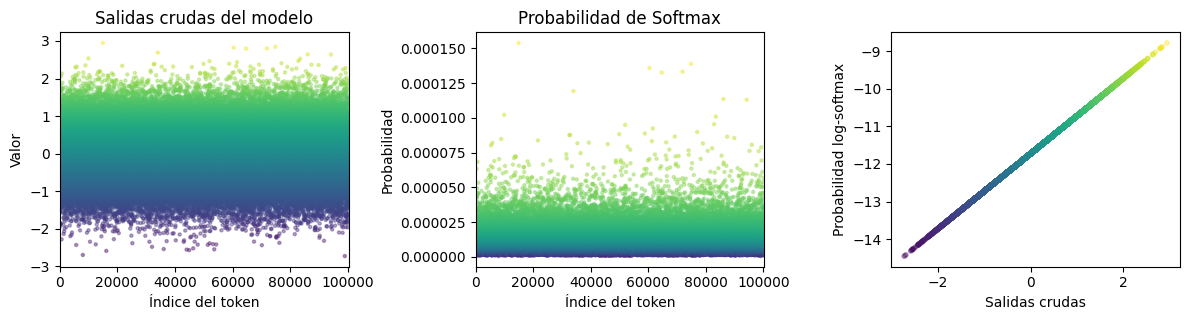

In [10]:
# Visualizar la salida de softmax
out = m(X)
final = out[-1, :].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


# Crear una figura
_, axs = plt.subplots(1, 3, figsize=(12, 3.3))

# Mostrar los logits (coloreado de logits crudos en todo el gráfico)
axs[0].scatter(range(len(final)), final, s=5, marker='o', c=final, alpha=0.4)
axs[0].set(
    title='Salidas crudas del modelo',
    xlabel='Índice del token',
    ylabel='Valor',
    xlim=[0, len(final)],
)

# Los logits convertidos por softmax (probabilidades)
axs[1].scatter(
    range(len(final)), softmaxFinal, s=5, marker='o', c=final, alpha=0.4
)
axs[1].set(
    title='Probabilidad de Softmax',
    xlabel='Índice del token',
    ylabel='Probabilidad',
    xlim=[0, len(final)],
)

# Su relación
axs[2].scatter(
    final, torch.log(softmaxFinal), s=10, marker='o', c=final, alpha=0.4
)
axs[2].set(xlabel='Salidas crudas', ylabel='Probabilidad log-softmax')

plt.tight_layout()
plt.show()

## Generar texto en batches

In [11]:
# También necesitamos un dataloader
dataloader = DataLoader(
    token_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

# Echemos un vistazo a los índices
X, y = next(iter(dataloader))
print(f'Entradas ({batch_size} lotes X {seq_len} tokens):')
print(X)

Entradas (5 lotes X 8 tokens):
tensor([[  315,  1148,   279, 13339,   358,  1047,  3970,  2643],
        [  198,  1820, 11018,   414,   315,  6730,   764,   269],
        [  376,   402,  6427,    13,  2435,   527, 87146, 47989],
        [ 8396,   449,  4868,   323, 11885,  2301,   439,   198],
        [  382,  2118, 13461,   420, 32692,  3242, 64476,  1053]])


In [12]:
# Obtener las salidas del modelo (logits)
out = m(X)
print(out.shape)  # lote X tokens X vocabulario
print(out)

torch.Size([5, 8, 100277])
tensor([[[-3.9847e-01,  1.0711e+00, -1.1256e+00,  ..., -1.4342e-01,
          -6.0707e-02, -7.6022e-02],
         [-1.1492e+00,  1.7402e-02, -7.3113e-02,  ...,  3.4128e-01,
          -5.7766e-01,  2.1278e-01],
         [-8.1025e-01,  1.1523e+00,  4.2080e-01,  ..., -1.0892e+00,
           2.5010e-01,  1.8841e-02],
         ...,
         [ 6.4839e-01,  6.4195e-01,  7.7936e-02,  ..., -8.5584e-02,
          -6.5733e-02, -4.9920e-01],
         [-1.9028e-01,  2.7078e-01, -5.2597e-01,  ...,  5.4024e-01,
          -4.0232e-02, -1.0216e+00],
         [ 3.1270e-01,  1.9469e-01,  4.9489e-01,  ..., -6.1096e-03,
           3.8776e-01, -5.2743e-02]],

        [[ 1.1613e-01,  3.8544e-01, -7.4750e-01,  ..., -5.7117e-04,
          -2.4044e-01, -6.6924e-02],
         [ 3.5320e-01, -1.2474e-01, -1.0726e+00,  ..., -1.1400e-01,
           5.6356e-01,  6.1879e-01],
         [-4.5917e-02,  8.2187e-01,  7.7591e-01,  ..., -8.7043e-01,
           1.1396e-01,  7.5963e-01],
         ...

In [13]:
# Generar algunos datos
gen_tokens = m.generate(X, temperature=1.3, n_new_tokens=8)
print(gen_tokens.shape)  # lote X (tokens+n_new_tokens)

torch.Size([5, 16])


In [19]:
# Repetir varias veces desde el mismo punto de partida
for batchtok in gen_tokens:
  print('\n--- SIGUIENTE EJEMPLO: ---\n')
  print(tokenizer.decode(batchtok.tolist()))


--- SIGUIENTE EJEMPLO: ---

 of what the meat I had seen might Ze Disfraureibung_decode INTERNATIONAL burgl seguro

--- SIGUIENTE EJEMPLO: ---


the odour of camphor-entry Thames SATAnavigatoririsHttpStatus Includes.name

--- SIGUIENTE EJEMPLO: ---

travelling. They are excessively unpleasant.durationPDFnormallyField acceler.parts Diy Swim

--- SIGUIENTE EJEMPLO: ---

 society with security and permanency as
holderIce}



 Compar Checked.Parcel(),
%%*/

--- SIGUIENTE EJEMPLO: ---

.

“Even this artistic impetus wouldcli frm Peyton certo automát itemprop Ves nett
